# Phase 2 — Feature Engineering: What We Did, and How



1. `sql/01`-`07_*.sql` -> `final_feature_table` (SQL layer: joins + window functions per source table)
2. `src/features/engineer_features.py` -> `engineered_features` (DTI, delinquency-recency blend, spending volatility, interaction)
3. `src/features/vif_check.py` (multicollinearity report)
4. `src/features/build_modeling_feature_set.py` -> `modeling_feature_set` (the curated table Phase 3 actually reads from)

If you ever need to rebuild the db from scratch: `python src/features/run_sql_pipeline.py` (add `--sample N` for a fast dev-scale run), then `engineer_features.py`, then `build_modeling_feature_set.py`.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DB_PATH = Path("..") / "data" / "processed" / "credit_risk.db"
conn = sqlite3.connect(DB_PATH)

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)

,name
0,application_time_signals
1,application_train
2,bureau
3,bureau_balance
4,bureau_features
5,credit_card_balance
6,credit_card_utilization_trend
7,cv_folds
8,engineered_features
9,final_feature_table


## Step 1 — The SQL layer: what each source table contributes

`run_sql_pipeline.py` loads the 7 raw CSVs into SQLite, then runs `sql/01`-`07_*.sql` in order. Each `0N_*.sql` script aggregates **one** raw table up to one row per `SK_ID_CURR` (a client can have many bureau records, many previous applications, many months of card/POS history — all of that gets collapsed via CTEs and window functions before it's allowed to join onto the application-level table). `07_final_feature_table.sql` then `LEFT JOIN`s every aggregate onto `application_train`.

**Why LEFT JOIN, not INNER JOIN:** not every applicant has bureau / previous-application / credit-card / POS-cash history. An INNER JOIN would silently drop those applicants. Instead, a LEFT JOIN keeps everyone, and a `has_*_history` flag makes "this applicant genuinely has no history here" explicit (rather than indistinguishable from a missing value later).

In [2]:
final = pd.read_sql("SELECT * FROM final_feature_table", conn)
print(f"final_feature_table: {final.shape[0]:,} rows x {final.shape[1]} columns")
final.head()

final_feature_table: 307,511 rows x 44 columns


,SK_ID_CURR,TARGET,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,is_weekend_application,is_night_application,bureau_total_credit_count,bureau_active_credit_count,bureau_closed_credit_count,bureau_avg_days_credit,...,cc_avg_utilization,cc_utilization_trend,cc_months_of_history,pos_completion_trend,pos_avg_dpd,pos_months_of_history,has_bureau_history,has_previous_application,has_credit_card_history,has_pos_cash_history
0,100002,1,WEDNESDAY,10,0,0,8.0,2.0,6.0,-874.00,...,NaN,NaN,NaN,0.708333,0.0,19.0,1,1,0,1
1,100003,0,MONDAY,11,0,0,4.0,1.0,3.0,-1400.75,...,NaN,NaN,NaN,0.805556,0.0,28.0,1,1,0,1
2,100004,0,MONDAY,9,0,0,2.0,0.0,2.0,-867.00,...,NaN,NaN,NaN,0.583333,0.0,4.0,1,1,0,1
3,100006,0,WEDNESDAY,17,0,0,NaN,NaN,NaN,NaN,...,0.0,0.0,6.0,0.666667,0.0,21.0,0,1,1,1
4,100007,0,THURSDAY,11,0,0,1.0,0.0,1.0,-1149.00,...,NaN,NaN,NaN,0.798235,0.0,66.0,1,1,0,1


### Where each column comes from

| Source script | Raw table aggregated | Columns produced |
|---|---|---|
| `01_bureau_features.sql` | `bureau` + `bureau_balance` | `bureau_total_credit_count`, `bureau_active_credit_count`, `bureau_closed_credit_count`, `bureau_avg_days_credit`, `bureau_days_since_last_credit`, `bureau_total_amt_credit_sum`, `bureau_total_amt_credit_sum_debt`, `bureau_credit_utilization`, `bureau_overdue_credit_count`, `bureau_avg_credit_term_days`, `bureau_months_since_last_delinquency` |
| `02_previous_application_features.sql` | `previous_application` | `prev_app_count`, `prev_app_approved_rate`, `prev_app_refused_rate`, `prev_app_avg_days_decision`, `prev_app_avg_amt_credit`, `prev_app_night_rate`, `prev_app_weekend_rate`, `prev_app_count_last_30d`, `prev_app_count_last_90d`, `prev_app_last_status` |
| `03_installments_features.sql` | `installments_payments` | `installments_count`, `installments_late_payment_rate`, `installments_avg_days_late`, `installments_avg_payment_ratio`, `installments_avg_repayment_velocity`, `installments_amt_volatility`, `days_since_last_late_payment` |
| `04_credit_card_utilization_trend.sql` | `credit_card_balance` | `cc_avg_utilization`, `cc_utilization_trend`, `cc_months_of_history` |
| `05_pos_cash_trend.sql` | `pos_cash_balance` | `pos_completion_trend`, `pos_avg_dpd`, `pos_months_of_history` |
| `06_application_time_signals.sql` | `application_train` (own columns) | `WEEKDAY_APPR_PROCESS_START`, `HOUR_APPR_PROCESS_START`, `is_weekend_application`, `is_night_application` |
| `07_final_feature_table.sql` | joins everything above | + `has_bureau_history`, `has_previous_application`, `has_credit_card_history`, `has_pos_cash_history` |

**Leakage-relevant details worth remembering** (from the `/leakage-check` pass, both confirmed clean but worth naming explicitly):
- `bureau_avg_credit_term_days` uses `DAYS_CREDIT_ENDDATE` (the *scheduled* term fixed at origination) — **not** `DAYS_CREDIT_ENDDATE_FACT`, which would leak the actual closure outcome.
- `prev_app_approved_rate` / `prev_app_refused_rate` / `prev_app_last_status` encode Home Credit's own past lending *decisions* — legitimate to use, but a qualitatively different kind of feature (decision history, not applicant behavior) worth flagging in the write-up.

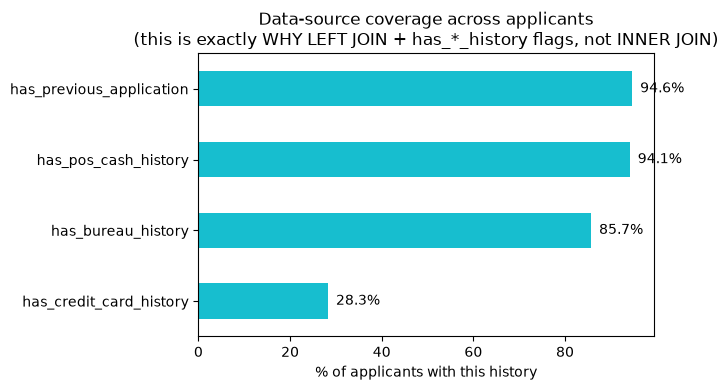

In [3]:
history_flags = ["has_bureau_history", "has_previous_application", "has_credit_card_history", "has_pos_cash_history"]
coverage = final[history_flags].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
coverage.sort_values().plot(kind="barh", ax=ax, color="tab:cyan")
ax.set_xlabel("% of applicants with this history")
ax.set_title("Data-source coverage across applicants\n(this is exactly WHY LEFT JOIN + has_*_history flags, not INNER JOIN)")
for i, v in enumerate(coverage.sort_values()):
    ax.text(v, i, f"  {v:.1f}%", va="center")
plt.tight_layout()
plt.show()

### A closer look: bureau features (the richest source table)

`bureau` + `bureau_balance` (27.3M rows) get collapsed to one row per `SK_ID_CURR`: counts of active/closed credit lines, total exposure, a utilization ratio (debt / credit sum), an overdue-credit count, and a delinquency-recency signal. This is the table most later phases lean on (it's also the source for two of the four synthetic-overlay drift features via `EXT_SOURCE_x`, though those actually come from `application_train`, not bureau — don't conflate the two).

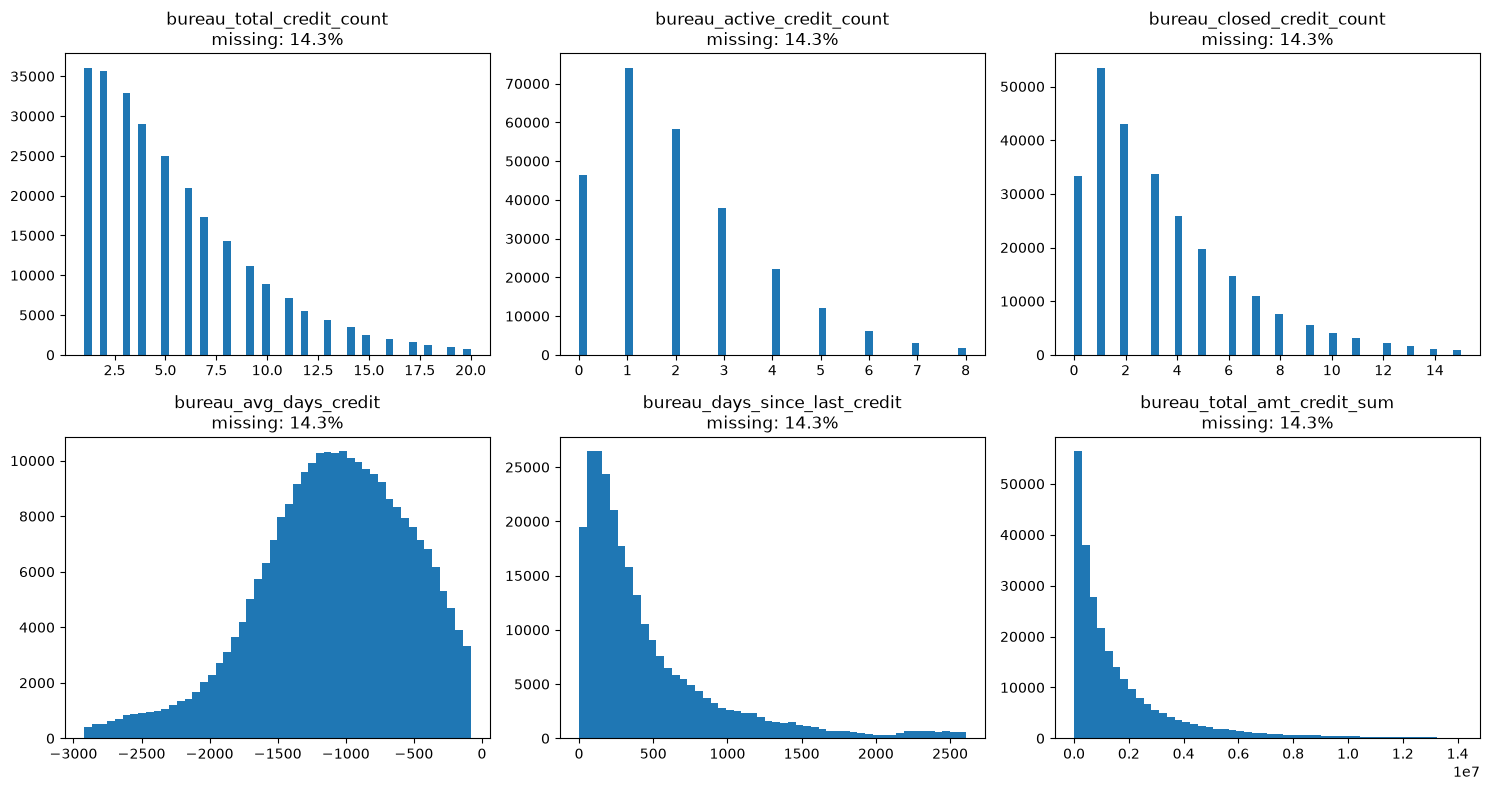

In [4]:
bureau_cols = [c for c in final.columns if c.startswith("bureau_")]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, bureau_cols[:6]):
    data = final[col].dropna()
    upper = data.quantile(0.99)
    ax.hist(data[data <= upper], bins=50, color="tab:blue")
    ax.set_title(f"{col}\nmissing: {100*final[col].isna().mean():.1f}%")
plt.tight_layout()
plt.show()

## Step 2 — Python-layer feature engineering (`engineer_features.py`)

Per CLAUDE.md's "one shared feature-engineering pipeline" rule, this script **reuses** columns already computed in SQL (`installments_avg_repayment_velocity`, the two recency columns) rather than recomputing them — it only adds what didn't already exist:

| New column | Formula | Why it's not just in SQL |
|---|---|---|
| `dti_ratio` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | Needs `application_train`'s own current-application amounts, joined at Python layer |
| `repayment_velocity` | = `installments_avg_repayment_velocity` (SQL) | Renamed for clarity only, not recomputed |
| `delinquency_recency_days` | `min(bureau_months_since_last_delinquency*30, days_since_last_late_payment)`, skipping NaN | Cross-source blend: whichever of bureau/installments reports the *more recent* bad event |
| `spending_volatility` | std. dev. of monthly `AMT_DRAWINGS_CURRENT` per card, averaged across a client's cards | Distinct from installment-*repayment* volatility — this is spending volatility (erratic spenders can be riskier at the same average spend) |
| `dti_utilization_interaction` | `dti_ratio * bureau_credit_utilization` | Interaction term; uses bureau utilization (85.7% coverage) over card utilization (28.3% coverage) so it stays defined for far more applicants |

In [5]:
engineered = pd.read_sql("SELECT * FROM engineered_features", conn)
print(f"engineered_features: {engineered.shape[0]:,} rows x {engineered.shape[1]} columns")

new_cols = ["dti_ratio", "repayment_velocity", "delinquency_recency_days", "spending_volatility", "dti_utilization_interaction"]
print("\nNull rate per engineered column:")
print((engineered[new_cols].isna().mean() * 100).round(1))

engineered.head()

engineered_features: 307,511 rows x 7 columns

Null rate per engineered column:
dti_ratio                       0.0
repayment_velocity              5.2
delinquency_recency_days       46.5
spending_volatility            71.9
dti_utilization_interaction    17.0
dtype: float64


,SK_ID_CURR,TARGET,dti_ratio,repayment_velocity,delinquency_recency_days,spending_volatility,dti_utilization_interaction
0,100002,1,0.121978,20.421053,570.0,NaN,0.034657
1,100003,0,0.132217,7.160000,NaN,NaN,0.000000
2,100004,0,0.100000,7.666667,NaN,NaN,0.000000
3,100006,0,0.219900,19.375000,NaN,0.0,NaN
4,100007,0,0.179963,3.636364,956.0,NaN,0.000000


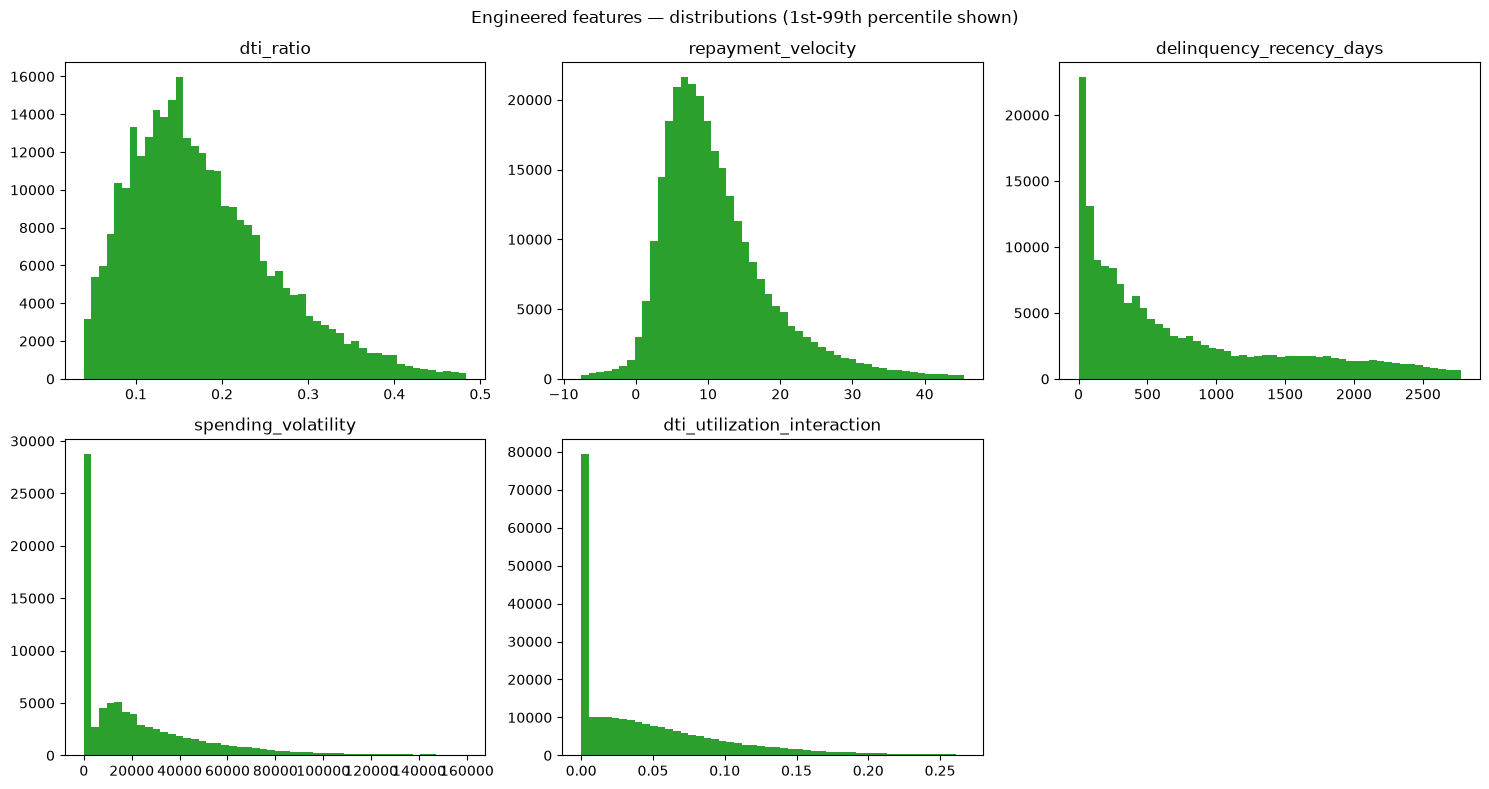

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, new_cols):
    data = engineered[col].dropna()
    lo, hi = data.quantile([0.01, 0.99])
    ax.hist(data[(data >= lo) & (data <= hi)], bins=50, color="tab:green")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.suptitle("Engineered features — distributions (1st-99th percentile shown)")
plt.tight_layout()
plt.show()

### Do the engineered features actually separate defaulters from non-defaulters?

A quick sanity check before trusting these go into modeling.

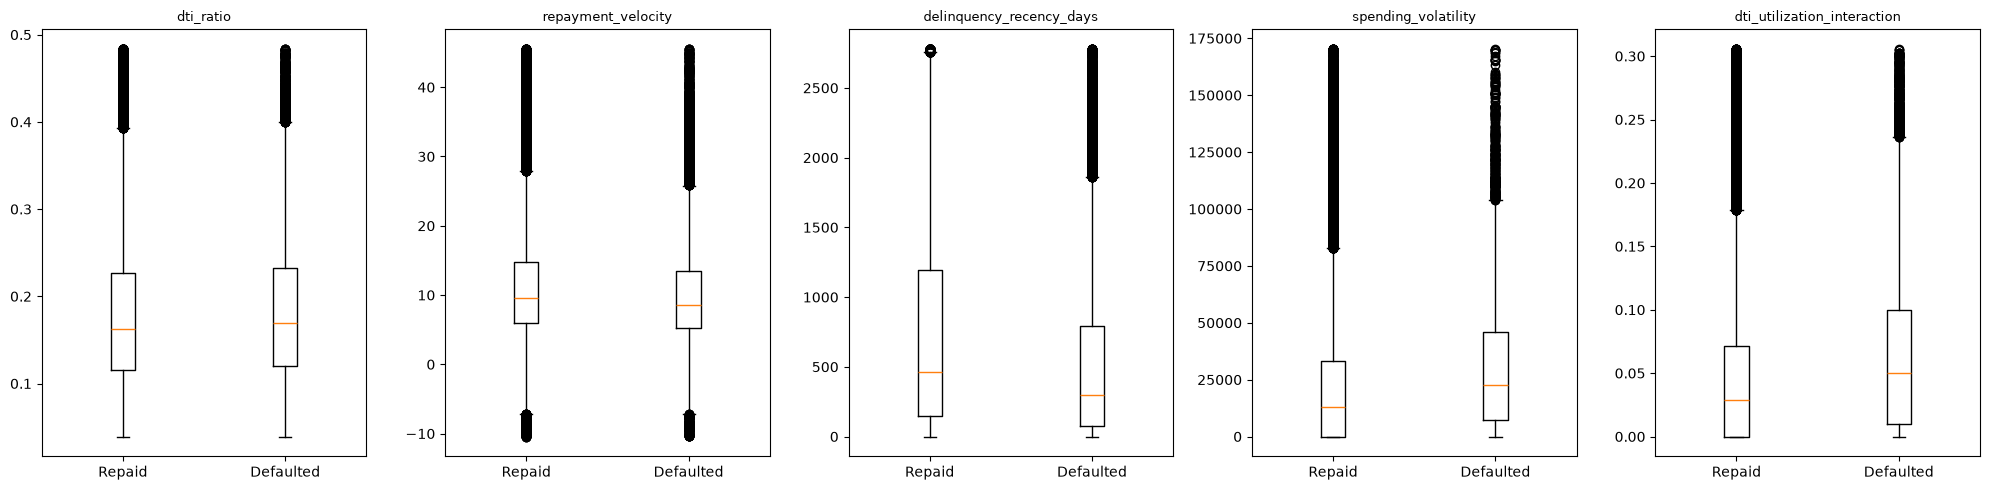

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)
for ax, col in zip(axes, new_cols):
    d0 = engineered.loc[engineered["TARGET"] == 0, col].dropna()
    d1 = engineered.loc[engineered["TARGET"] == 1, col].dropna()
    lo = min(d0.quantile(0.01), d1.quantile(0.01))
    hi = max(d0.quantile(0.99), d1.quantile(0.99))
    ax.boxplot(
        [d0[(d0 >= lo) & (d0 <= hi)], d1[(d1 >= lo) & (d1 <= hi)]],
        tick_labels=["Repaid", "Defaulted"],
    )
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

## Step 3 — Multicollinearity check (`vif_check.py`)

VIF (Variance Inflation Factor) measures how much a feature's variance is inflated because it's linearly predictable from the *other* features. VIF > 10 is the usual red flag. This check runs on `final_feature_table` + `engineered_features` combined, **median-imputed for this check only** (not the project's real imputation strategy — that's a train-only fit in Phase 3).

This was a report-only pass — nothing gets dropped inside `vif_check.py` itself. The actual drop decision happens in `build_modeling_feature_set.py` (Step 4 below), and only for columns verified redundant by direct evidence, not by VIF score alone.

In [1]:
%run ../src/features/vif_check.py

Computing VIF over 45 numeric features, n=307,511 rows (median-imputed for this check only)



C:\Users\ASUS\miniconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                             feature         VIF
 installments_avg_repayment_velocity         inf
                  repayment_velocity         inf
           bureau_total_credit_count 1522.428674
          bureau_closed_credit_count  731.043361
          bureau_active_credit_count  235.226841
            has_previous_application   90.109970
                has_pos_cash_history   81.243988
                  has_bureau_history   33.991350
              prev_app_approved_rate   22.490245
                pos_completion_trend   21.817900
        days_since_last_late_payment   17.484118
                  installments_count   17.312160
            delinquency_recency_days   15.666721
             HOUR_APPR_PROCESS_START   15.641300
              bureau_avg_days_credit   13.754615
               pos_months_of_history   12.847725
                cc_months_of_history   10.243718
                      prev_app_count    7.591888
         dti_utilization_interaction    7.047793
                    

In [4]:
top20 = vif_df.head(20)
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["red" if v > 10 else "gray" for v in top20["VIF"]]
ax.barh(top20["feature"][::-1], top20["VIF"][::-1], color=colors[::-1])
ax.axvline(10, color="black", linestyle="--", label="VIF = 10 threshold")
ax.set_xlabel("VIF")
ax.set_title("Top 20 features by VIF (before dropping anything)")
ax.legend()
plt.tight_layout()
plt.show()

NameError: name 'vif_df' is not defined

## Step 4 — Curating `modeling_feature_set` (`build_modeling_feature_set.py`)

Three columns were dropped — each verified redundant by **direct evidence**, not by VIF score or name alone:

| Dropped column | Reason (verified) |
|---|---|
| `installments_avg_repayment_velocity` | Exact duplicate of `repayment_velocity` (VIF = inf on both — literally the same values) |
| `bureau_total_credit_count` | Equals `bureau_active_credit_count + bureau_closed_credit_count` for 98.0% of rows exactly — an arithmetic identity. Kept the active/closed split since it carries the same info plus a free breakdown |
| `days_since_last_late_payment` | r = 0.934 with `delinquency_recency_days`, which is `min(days_since_last_late_payment, bureau_months_since_last_delinquency*30)` by construction — a strict superset. Kept the unified column |

**Deliberately NOT dropped** (kept for Phase 3 to decide, once an imputation strategy exists):
- The 4 `has_*_history` flags — each is a deterministic function of "is the paired count/months column non-null", but once NaNs get imputed in Phase 3, these flags become the *only* way to tell "genuinely zero" apart from "missing." Dropping them now would destroy that distinction permanently.
- The remaining ~9 VIF-flagged columns (`installments_count`, `pos_months_of_history`, `cc_months_of_history`, `pos_completion_trend`, `prev_app_approved_rate`, `HOUR_APPR_PROCESS_START`, `bureau_avg_days_credit`, etc.) reflect a genuine shared "history depth" latent factor across several columns at once — not pairwise duplication. Handled instead via L2/Ridge regularization on Logistic Regression in Phase 3 (tree models are unaffected by this kind of collinearity anyway).

In [3]:
modeling = pd.read_sql("SELECT * FROM modeling_feature_set", conn)
print(f"modeling_feature_set: {modeling.shape[0]:,} rows x {modeling.shape[1]} columns")
print(f"final_feature_table had {final.shape[1]} cols + engineered_features added 5 -> "
      f"{final.shape[1] + 5} before dropping -> {modeling.shape[1]} after dropping 3")

dropped_cols = ["installments_avg_repayment_velocity", "bureau_total_credit_count", "days_since_last_late_payment"]
assert not any(c in modeling.columns for c in dropped_cols), "a dropped column is still present"
print("\nConfirmed dropped:", dropped_cols)
modeling.head()

NameError: name 'conn' is not defined

## Summary: the full Phase 2 pipeline at a glance

In [5]:
summary = pd.DataFrame([
    {"stage": "final_feature_table (SQL, 01-07)", "rows": final.shape[0], "cols": final.shape[1]},
    {"stage": "engineered_features (Python)", "rows": engineered.shape[0], "cols": engineered.shape[1]},
    {"stage": "modeling_feature_set (curated, VIF-informed)", "rows": modeling.shape[0], "cols": modeling.shape[1]},
])
summary

NameError: name 'final' is not defined

In [ ]:
conn.close()